# Now this is class1, week1 homework
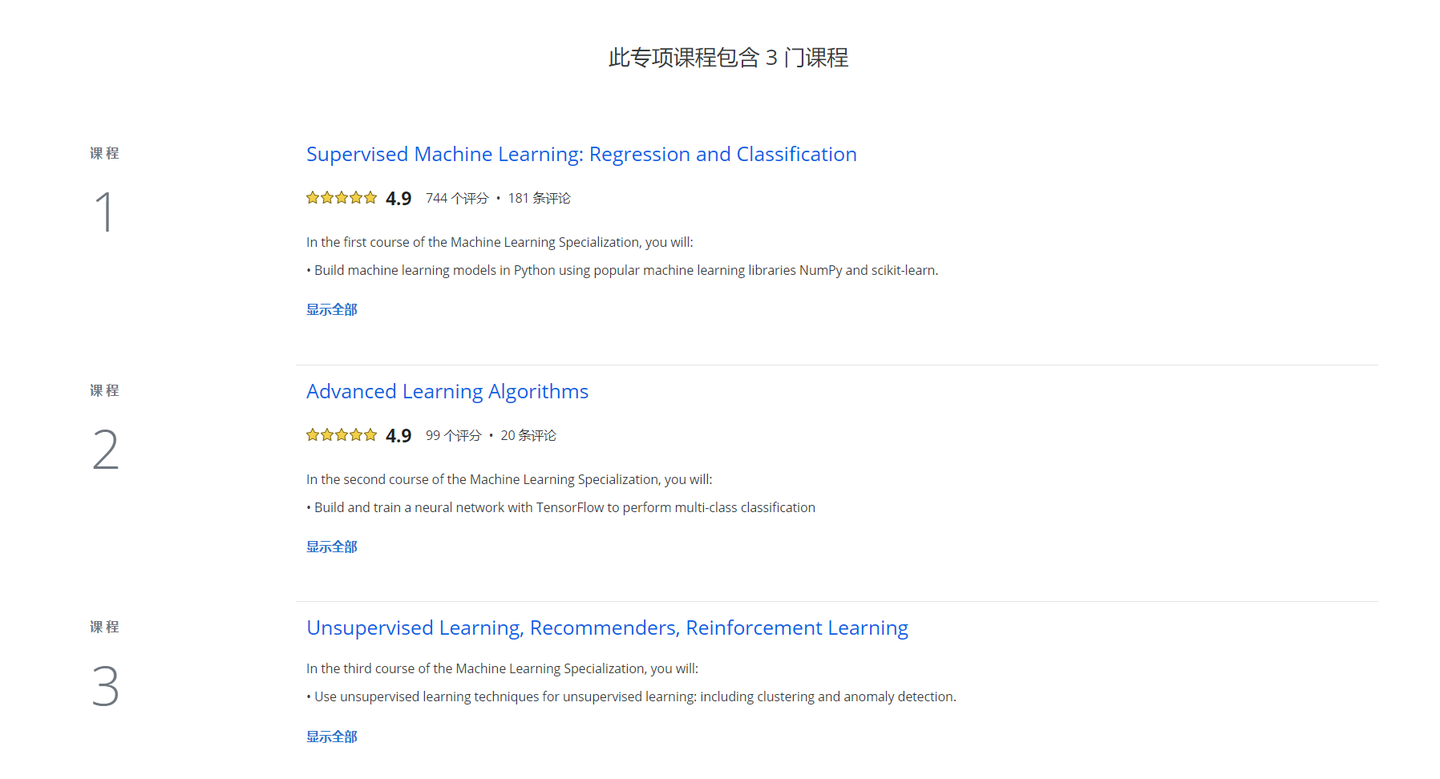

## begin with a quizzes
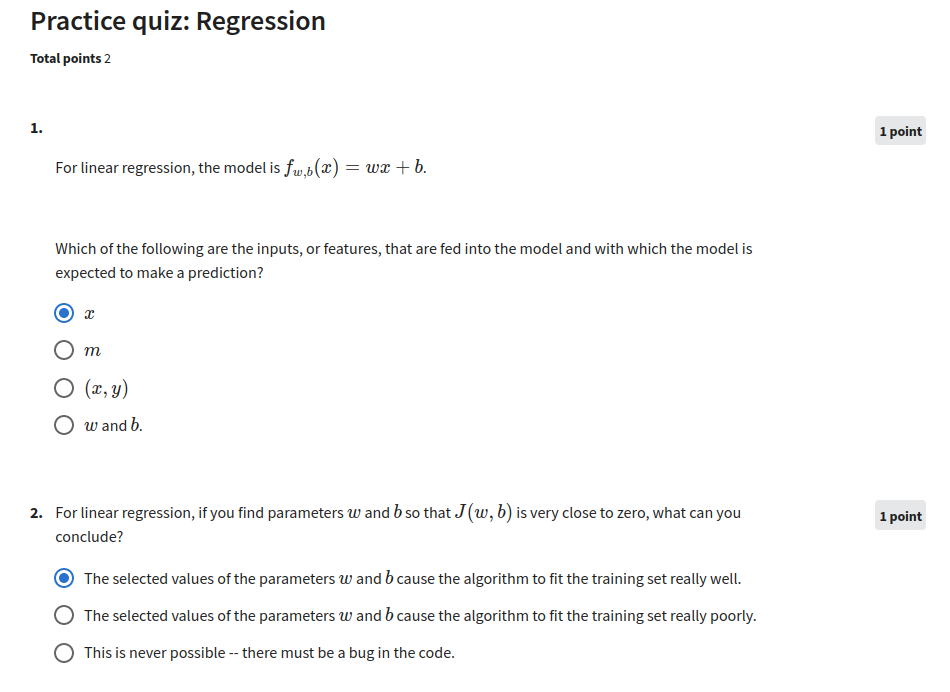
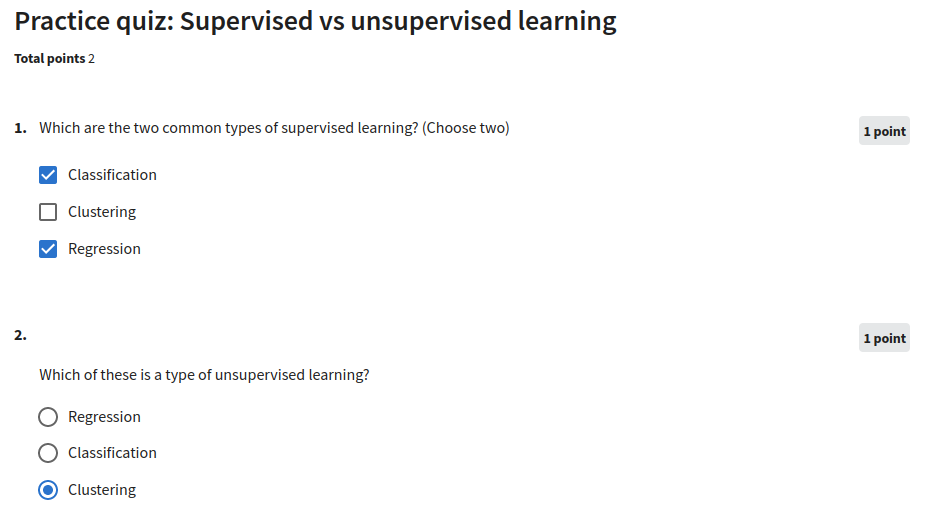 
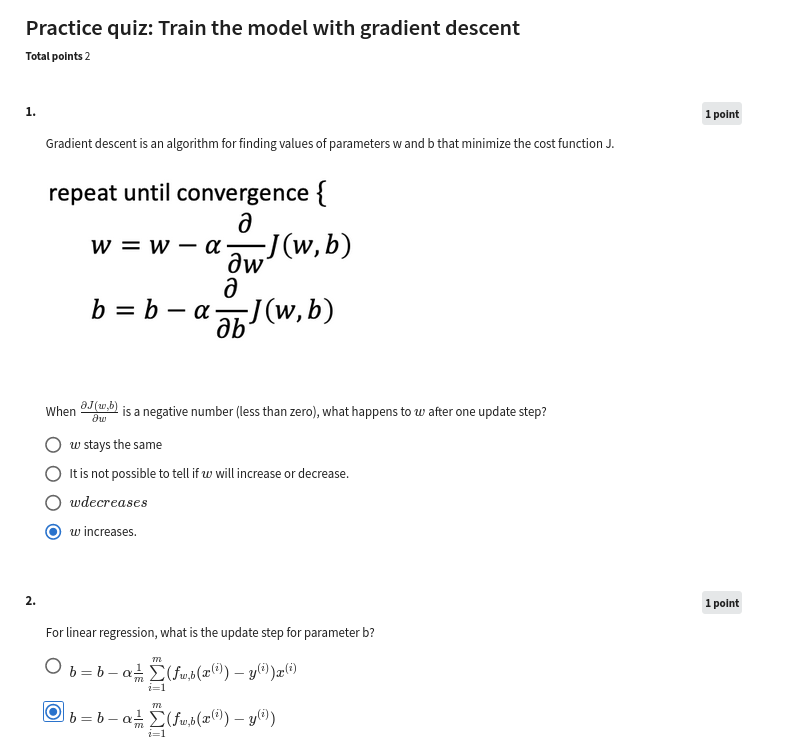

# 模型描述
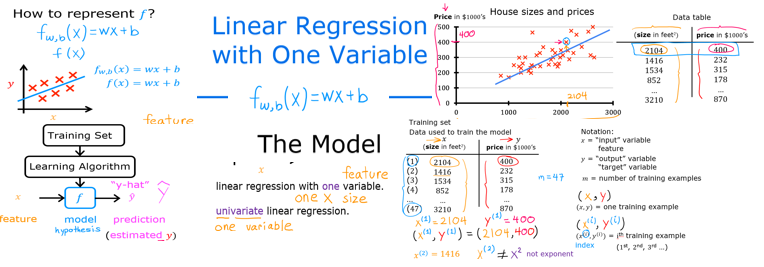

## 二、符号
| 一般符号 | 描述 | Python 变量名（如果有） |
|---------|------|------------------------|
| $a$ | 标量，非粗体 | |
| **a** | 矢量，粗体 | |
| 回归 | | |
| x | 训练实例特征值 (本实验室 - 面积 (1000 sqft)) | x_train |
| y | 训练实例标签值 (本实验室 - 价格 (1000s of dollars)) | y_train |
| $x^{(i)}$, $y^{(i)}$ | $i_{th}$ 训练实例 | x_i, y_i |
| m | 训练样本数 | m |
| $w$ | 参数：权重 | w |
| $b$ | 参数：偏置 | b |
| $f_{w,b}(x^{(i)})$ | 模型评估的结果为 $x^{(i)}$ 参数为 $w, b$: <br> $f_{w,b}(x^{(i)}) = wx^{(i)} + b$ | f_wb |


## 三、工具（函数库）

In [1]:
import sys
import os
# 获取当前notebook所在目录
current_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.append(current_dir)
import numpy as np
import matplotlib.pyplot as plt
# 使用相对路径找到style文件
style_path = os.path.join(os.path.dirname(current_dir), '..', 'deeplearning.mplstyle')
plt.style.use(style_path)
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

## 四、问题引入
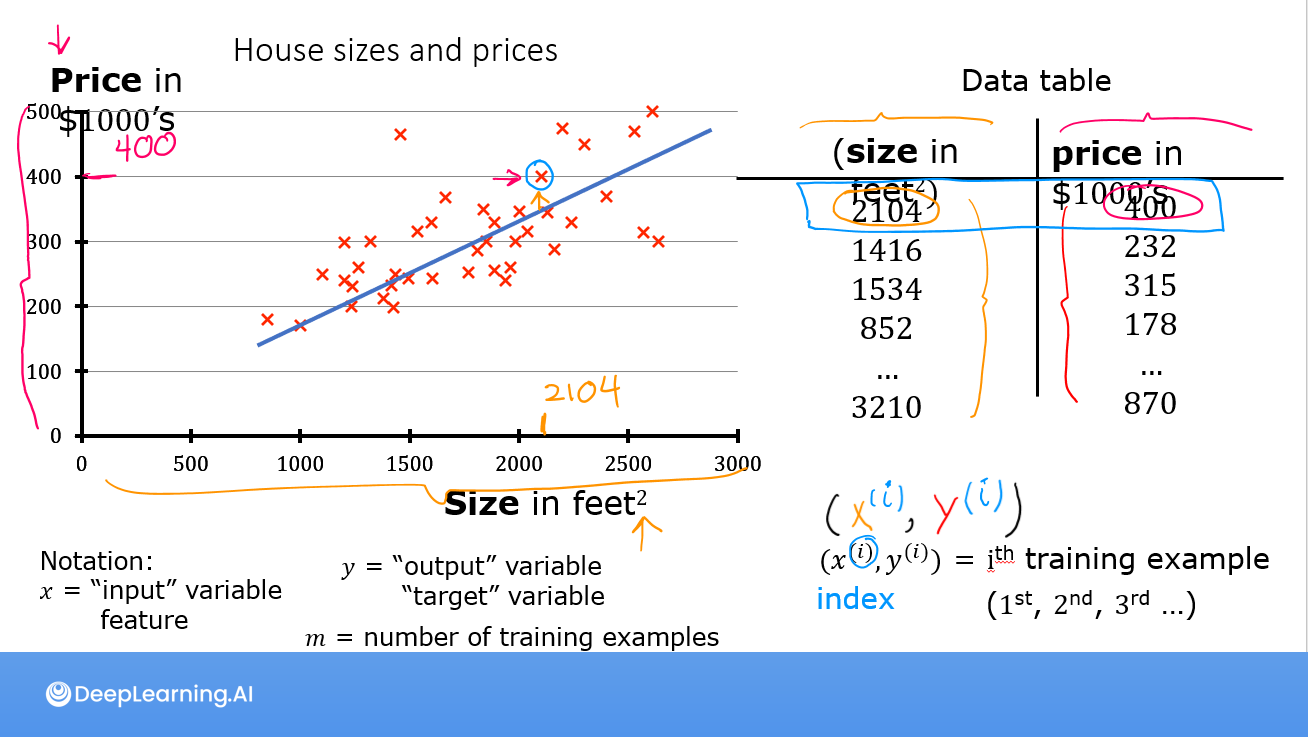
#### 
与课程中一样，你将使用住房价格预测的例子。
这个例子将使用一个只有两个数据点的简单数据集 ：一个1000平方英尺（sqft）的房子以300,000美元售出，一个2000平方英尺的房子以500,000美元售出。这两个点将构成我们的 数据或训练集 。在这个例子里，面积的单位是1000平方英尺，价格的单位是1000美元。

|面积 (1000 sqft)	|价格 (1000s of dollars)|
|---------------|------------|
|1.0	|300|
|2.0	|500|

你想通过这两点拟合一个线性回归模型（如上图蓝色直线所示），这样你就可以预测其他房子的价格 - 比如说，一个1200平方英尺的房子。

请运行以下代码单元来创建你的 x_train 和 y_train 变量。数据被存储在一维NumPy数组中。

In [2]:
# 建立数据集
x_train = np.array([1.0, 2.0])
y_train = np.array([300, 500])

### 训练例子的数量m
你将使用m来表示训练实例的数量。 Numpy数组有一个.shape参数。x_train.shape返回一个python数组，每个元素表示一个维度。x_train.shape[0]是数组的长度和例子的数量，如下所示。 **记住：.shape 后面不加 ()，因为它是属性不是函数。**

In [3]:
print('Number of training examples is:{x_train.shape}')
print(f'Number of training examples is:{x_train.shape}')
print(x_train.shape)
print(f'Number of training examples is:{x_train.shape[0]}')
print(f'Number of training examples is:{len(x_train)}')

Number of training examples is:{x_train.shape}
Number of training examples is:(2,)
(2,)
Number of training examples is:2
Number of training examples is:2


### 训练实例 `x_i, y_i'
你将使用 $(x^{(i)}, y^{(i)})$ 来表示第 $i^{th}$ 个训练实例。由于 Python 是零索引的，$(x^{(0)}, y^{(0)})$ 是 (1.0, 300.0)，$(x^{(1)}, y^{(1)})$ 是 (2.0, 500.0)。

要访问 Numpy 数组中的一个值，需要用所需的偏移量来索引该数组。例如，访问 x_train 的零号位置的语法是 x_train[0]。

运行下面的代码块以获得 $i^{th}$ 训练实例。


### 绘制数据
你可以使用matplotlib库中的scatter()函数绘制这两个点，如下面的单元格所示。

函数参数marker和c将点显示为红色十字（默认为蓝色点）。
你可以使用matplotlib库中的其他函数来设置要显示的标题和标签

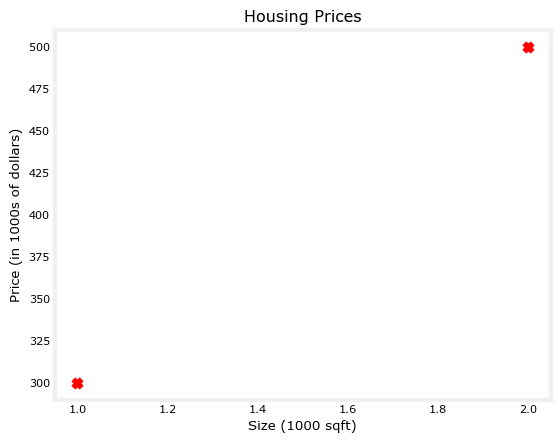

In [4]:
plt.scatter(x_train, y_train, marker='x', c='r')#c is color
# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Size (1000 sqft)')
plt.show()

## 五、模型fun
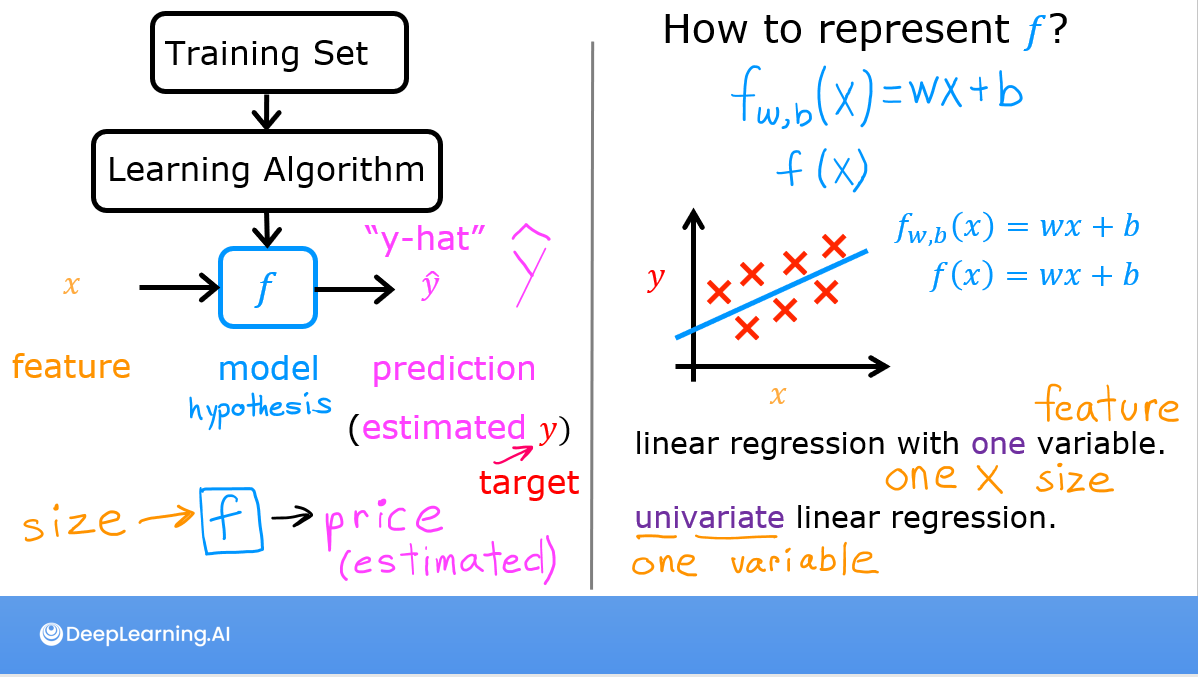
如课程中所述，线性回归的模型函数（是一个从x映射到y的函数）表示为

$$f_{w,b}(x^{(i)}) = wx^{(i)} + b$$

上面的公式是代表了一条直线——$w$ 和 $b$ 的不同值在图上给你不同的直线。

让我们试着通过下面的代码块来获得一个更好的直觉。让我们从 $w = 100$ 和 $b = 100$ 开始。


In [5]:
w = 200
b = 100
print(f"w is {w}")
print(f"b is {b}")


w is 200
b is 100


现在，让我们计算一下两个数据点的 $f_{w,b}(x^{(i)})$ 的值。你可以把每个数据点的数值明确写成：

对于 $x^{(0)}$，f_wb = w * x[0] + b

对于 $x^{(1)}$，f_wb = w * x[1] + b

对于大量的数据点，这可能会变得笨重和重复。因此，你可以在一个 for 循环中计算函数的输出，如下面的 compute_model_output 函数所示。

> 注意。参数描述 (ndarray (m,)) 描述了一个 Numpy 的 n 维数组的形状 (m,)。(scalar) 描述了一个没有维度的参数，只有一个标量。
> 
> 注意。np.zero(n) 将返回一个有 n 项的一维 numpy 数组。


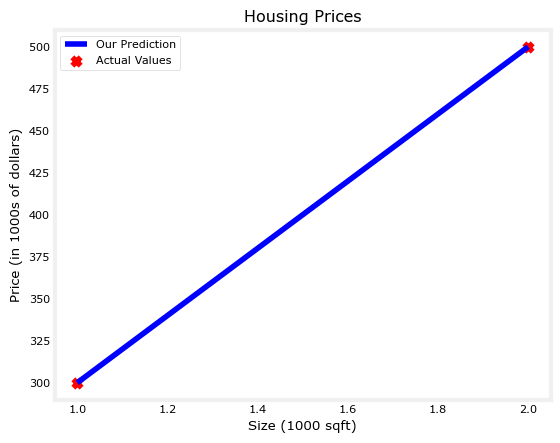

In [6]:
def compute_model_output(x, w, b):
    #m = x.shape m = x.shape 返回的是元组 (2,)，不能直接用作整数。
    m = x.shape[0]
    
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb

tmp_f_wb = compute_model_output(x_train, w, b)
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')
# 设置标题
plt.title("Housing Prices")
# 设置y轴标签
plt.ylabel('Price (in 1000s of dollars)')
# 设置x轴标签
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

试着用w和b的不同值进行实验。找到拟合我们数据的直线应该是什么值？

### 预测
现在我们有了一个模型，我们可以用它来做我们最初的预测。让我们来预测一个1200平方英尺的房子的价格。由于的单位是1000平方英尺，x是1.2。

In [7]:
x_i = 1.2
predict_1200 = w * x_i + b
print(f"Price of a house with 1200 sqft is {predict_1200} thousand dollars")


Price of a house with 1200 sqft is 340.0 thousand dollars


# 成本函数
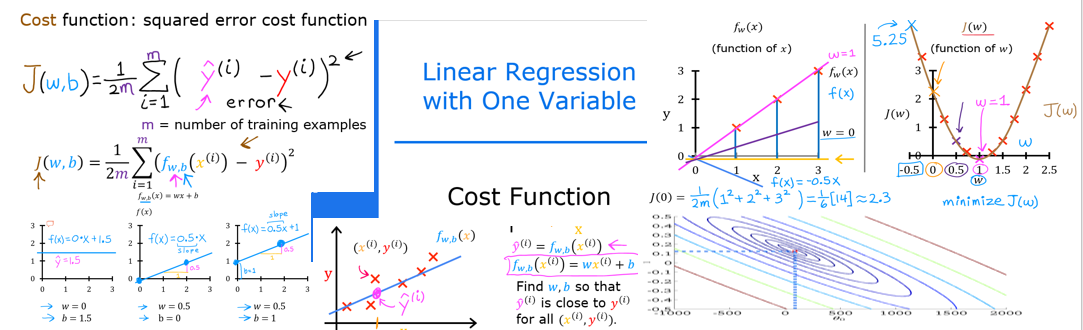

In [8]:
from lab_utils_uni import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl

## 一、问题陈述
你想建立一个模型，可以根据房子的大小来预测住房价格。
让我们使用与前一个例子相同的两个数据点 - 一个1000平方英尺的房子以300,000美元售出，一个2000平方英尺的房子以500,000美元售出。

|Size (1000 sqft)	|Price (1000s of dollars)|
|------------|-------------|
|1	|300|
|2	|500|
## 二、引入成本函数
"成本"一词可能有点令人困惑，因为我们今天使用的数据有关住房成本。所以注意在这里，成本是衡量我们的模型对房屋的目标价格的预测程度，而"价格"一词则用于住房数据。

一个变量的成本方程式是：

$$J(w, b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$

其中，

$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$

- $f_{w,b}(x^{(i)})$ 是在参数 $w, b$ 下，我们对第 $i$ 个例子的预测
- $(f_{w,b}(x^{(i)}) - y^{(i)})^2$ 是目标值和预测值之间的平方差。
- 将所有 $m$ 个例子的平方差相加，除以 2m，得出成本，$J(w, b)$

> 注意，在课上，求和范围通常是从 1 到 m，而代码将从 0 到 m-1。

> 线性回归的成本函数，$J(w,b)$其实是MSE均方误差公式 （Mean Squared Error, MSE）

下面的代码通过对每个例子的循环来计算成本。在每个循环中：

- f_wb，计算预测值
- 计算目标值和预测值之间的差值，并对其进行平方
- 这结果累加到总成本中


In [9]:
def compute_cost(x, y, w, b):
    m =  x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i])**2
        cost_sum = cost_sum + cost
    total_cost = (1/(2*m))*cost_sum
    return total_cost

## 三、成本函数直观表示
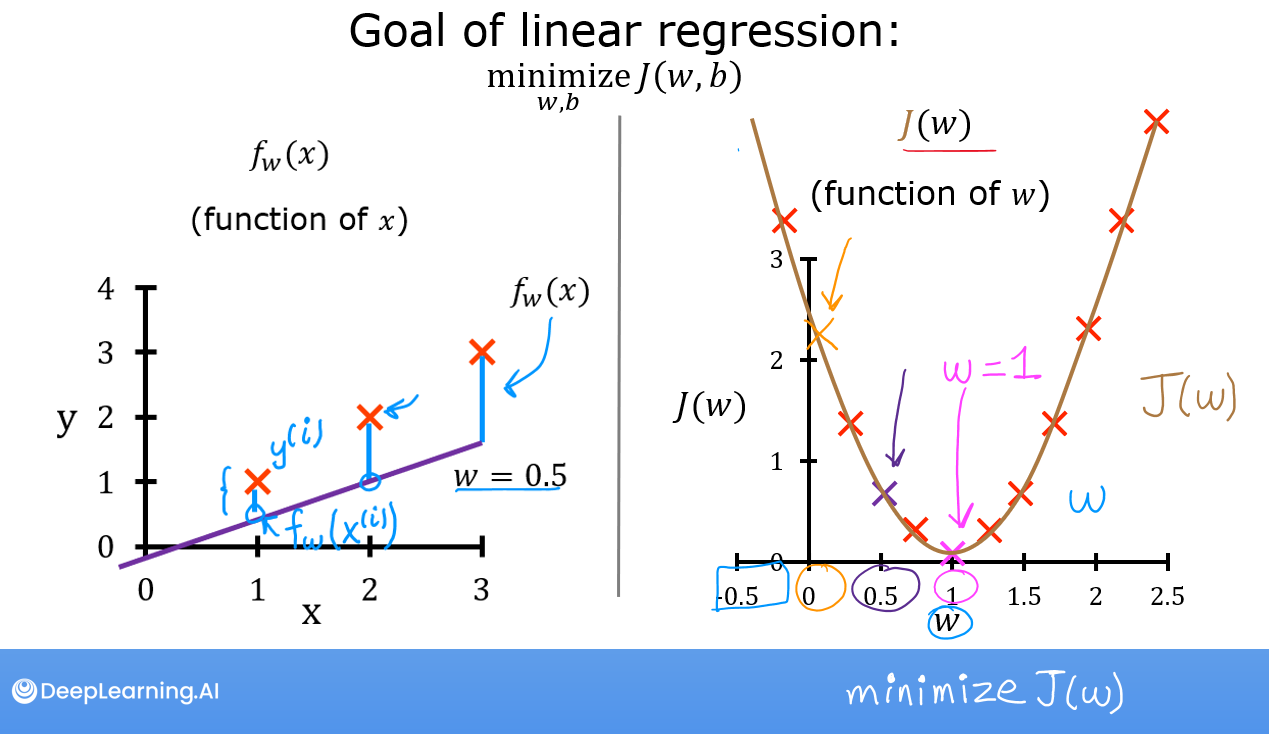

你的目标是找到一个模型 $f_{w,b}(x) = wx + b$，其参数为 $w, b$，该模型将准确预测输入 $x$ 的房屋价值。成本是衡量该模型在训练数据上的准确程度。

上面成本方程 (1) 表明，如果可以选择 $w$ 和 $b$，使预测结果 $f_{w,b}(x)$ 与目标数据 $y$ 匹配，则 $(f_{w,b}(x^{(i)}) - y^{(i)})^2$ 项将为零，成本最小化。在这个简单的两个数据点的例子中，你可以实现这个目标！

在上一个实验中，你确定 $b = 100$ 提供了一个最优解，所以让我们把 $b$ 设为 100，并关注 $w$。

下面，使用滑块控制来选择成本最小的 $w$ 值。该图可能需要几秒钟的时间来更新。


In [10]:
plt_intuition(x_train, y_train)

interactive(children=(IntSlider(value=150, description='w', max=400, step=10), Output()), _dom_classes=('widge…


该图包含几个值得一提的要点:

- 当w = 200时，成本最小，这与前一个实验室的结果一致
- 因为在成本方程中，目标值和预测值之间的差值会取平方，所以当
- 过大或过小时，成本迅速增加。
- 使用通过最小化成本选择的w和b可以得到一条与数据完全吻合的直线。

## 四、成本函数可视化
你可以通过3D绘图或使用等高线图来观察成本如何随w和b的变化而变化。
值得注意的是，本课程中的一些绘图可能变得相当复杂。绘图例程是提供的，虽然通过阅读代码来熟悉这些方法是很有意义的，但要成功完成本课程并不需要。这些程序在input目录下的lab_utils_uni.py中。


### 更大的数据集
用更多的数据点来查看一个场景是很有启发的。这个数据集包括不落在同一直线上的数据点。这对成本方程意味着什么？我们能否找到
和
，使我们的成本为0？

In [11]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

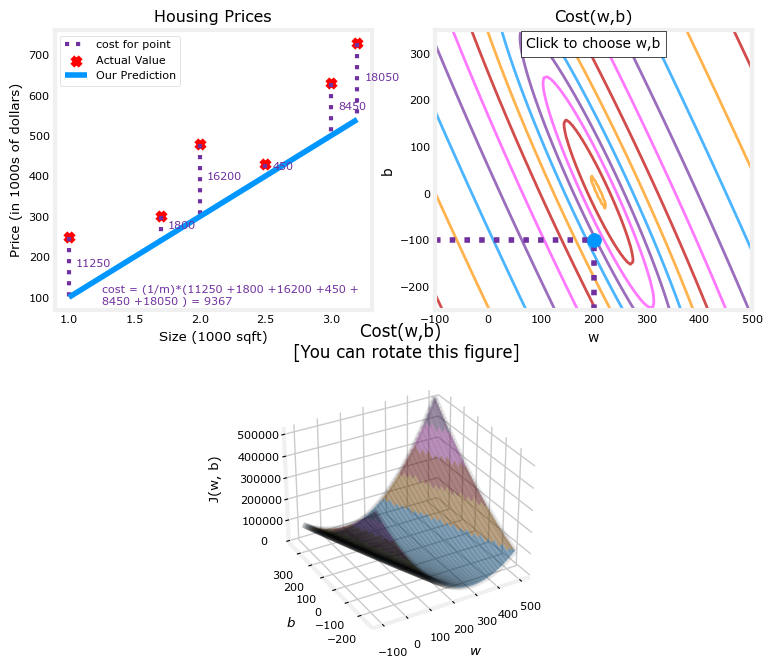

In [12]:
plt.close('all') 
fig, ax, dyn_items = plt_stationary(x_train, y_train)
updater = plt_update_onclick(fig, ax, x_train, y_train, dyn_items)

## 五、线性回归的梯度下降
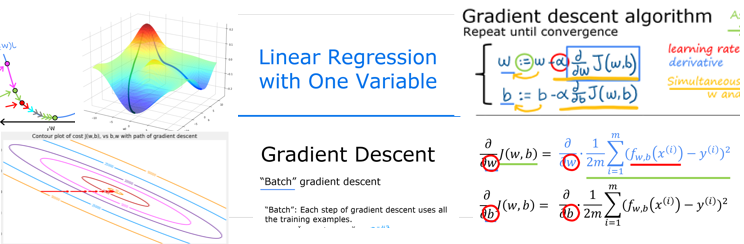

### 目标：使用梯度下降法使w和b的优化过程自动化。

In [13]:
# Load our data set
x_train = np.array([1.0, 2.0])   #features
y_train = np.array([300.0, 500.0])   #target value

### 实现梯度下降

你将为一个特征实现梯度下降算法。你将需要三个函数：

- **compute_gradient** 实现上述公式(4)和(5)
- **compute_cost** 实现上述公式(2)(上一个实验的代码)
- **梯度下降**，利用compute_gradient和compute_cost

模例：

- 包含偏导数的ipython变量的命名遵循这个模式，$\frac{\partial J(w,b)}{\partial b}$ 将是dj_db
- w.r.t是指With Respect To（关于），如 $J(wb)$ 关于 $b$ 的偏导数

计算梯度

compute_gradient实现了上述(4)和(5)，并返回 $\frac{\partial J(w,b)}{\partial w}$，$\frac{\partial J(w,b)}{\partial b}$。嵌入的注释描述了这些操作。



In [14]:
def compute_gradient(x, y, w, b):
    """ 
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range (m):
        f_wb = w *x[i] + b        
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_dw += dj_dw_i       
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_db, dj_dw


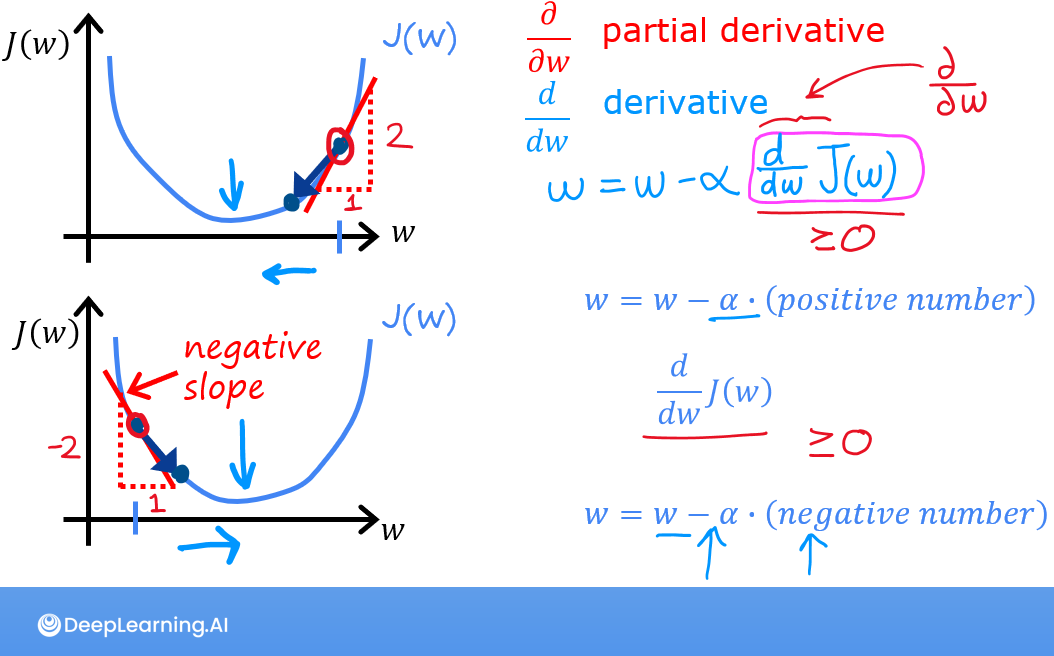
讲座描述了梯度下降是如何利用成本相对于某一点的参数的偏导来更新该参数的。

让我们使用compute_gradient函数来寻找并绘制成本函数相对于其中一个参数w₀的一些偏导数。

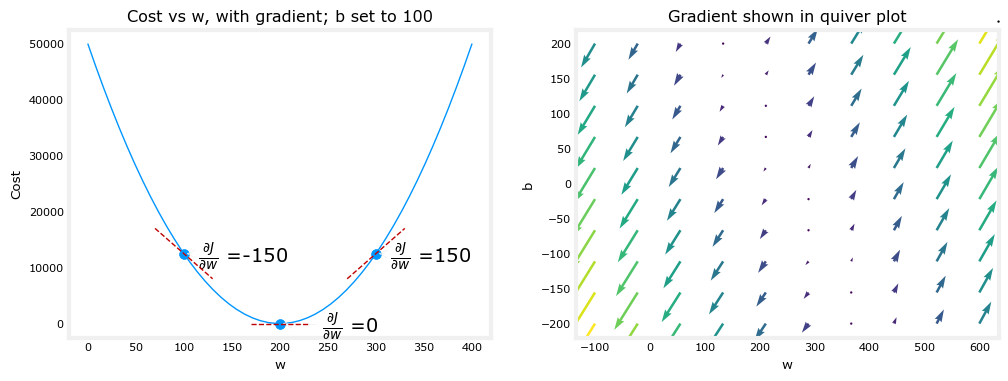

In [15]:
plt_gradients(x_train,y_train, compute_cost, compute_gradient)
plt.show()

上面，上边的图显示了 $\frac{\partial J(w,b)}{\partial w}$ 或成本曲线相对于w在三点的斜率。在图的右边，导数是正的，而在左边则是负的。由于"碗的形状"，导数将总是导梯度下降到梯度为零的底部。

上边的图固定了 $b = 100$。梯度下降将利用 $\frac{\partial J(w,b)}{\partial w}$ 和 $\frac{\partial J(w,b)}{\partial b}$ 来更新参数。右边的"四维图"提供了一种查看两个参数梯度的方法。箭头的大小反映了该点的梯度的大小。箭头的方向和斜率反映了 $\frac{\partial J(w,b)}{\partial w}$ 和 $\frac{\partial J(w,b)}{\partial b}$ 在该点的比率。

请注意，梯度指向远离最小值的地方。回顾上面的公式（3）。按比例的梯度是从 $w$ 或 $b$ 的当前值中减去的。这将使参数向减少成本的方向移动。

### 梯度下降
现在可以计算梯度了，上面公式(3)中描述的梯度下降可以在下面的gradient_descent中实现。实现的细节将在注释中描述。下面，你将利用这个函数在训练数据上找到w和b的最佳值。

In [16]:

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    w = copy.deepcopy(w_in)  # avoid modifying global w_in
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_db, dj_dw = gradient_function(x, y, w, b)

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        # Save cost J at each iteration
        if i < 100000:  # prevent resource exhaustion
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w, b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"w: {w: 0.3e}, b:{b: 0.3e}")

    return w, b, J_history, p_history  # return w and J,w history for graphing

    